<a href="https://colab.research.google.com/github/lnghan/MC311-Analysis/blob/main/2-eda/notebooks/le_capstone_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Han Le
# DATA 205 Project EDA Part



---



In [36]:
# Upload cleaned datasets (MC311 + Weather, ZIP Code)

from google.colab import files
uploaded = files.upload()

Saving zip_codes_clean.csv to zip_codes_clean (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [89]:
mc311 = pd.read_csv('mc311_weather_clean.csv')
zips = pd.read_csv('zip_codes_clean.csv')

In [93]:
merged = pd.merge(mc311, zips, on='city_name', how='left')

# Remove duplicate zip_code column
merged = merged.drop(columns=['zip_code_y'])
merged = merged.rename(columns={'zip_code_x': 'zip_code'})

merged.head()

,id,date_opened,date_closed,status,response_time,sla_days,within_sla,zip_code,city_name,department,...,housing_units,white,black,american_indian,asian,native_hawaiian,non_hispanic_other,hispanic,population_65_plus,med_age
0,1583125970,2025-01-01,2025-01-07,Closed,6.0,60.0,Yes,20904,Colesville,DHCA,...,21452,14560,22696,81,7533,34,216,8061,8192,38.0
1,1583126482,2025-01-01,2025-01-15,Closed,14.0,3.0,No,20853,Rockville,DOT,...,10035,15086,3188,67,3508,10,130,7115,4706,41.4
2,1583126709,2025-01-01,2025-01-14,Closed,13.0,3.0,No,20904,Colesville,DOT,...,21452,14560,22696,81,7533,34,216,8061,8192,38.0
3,1583126729,2025-01-01,2025-01-02,Closed,1.0,3.0,Yes,20866,Burtonsville,DOT,...,4652,3483,5703,30,2402,6,59,1287,1022,36.5
4,1583154935,2025-01-02,2025-01-07,Closed,5.0,5.0,Yes,20833,Brookeville,DOT,...,2545,5624,687,6,678,0,30,521,777,42.5


In [5]:
mc311.head()

,id,date_opened,date_closed,status,response_time,sla_days,within_sla,zip_code,city_name,department,area,area_topic,date,prcp,max_temp,min_temp,avg_temp,day_of_week,month
0,1583125970,2025-01-01,2025-01-07,Closed,6.0,60.0,Yes,20904,Colesville,DHCA,Code Enforcement,Housing Complaints,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
1,1583126482,2025-01-01,2025-01-15,Closed,14.0,3.0,No,20853,Rockville,DOT,Highway Services,Pothole Repair,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
2,1583126709,2025-01-01,2025-01-14,Closed,13.0,3.0,No,20904,Colesville,DOT,Highway Services,Pothole Repair,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
3,1583126729,2025-01-01,2025-01-02,Closed,1.0,3.0,Yes,20866,Burtonsville,DOT,Highway Services,Pothole Repair,2025-01-01,0.0,51.0,42.0,46.5,Wednesday,January
4,1583154935,2025-01-02,2025-01-07,Closed,5.0,5.0,Yes,20833,Brookeville,DOT,Highway Services,Roadway Resurfacing or Repaving,2025-01-02,0.0,42.0,37.0,39.5,Thursday,January


In [90]:
zips.head()

,zip_code,med_household_income,med_individual_income,percent_under_18,population,housing_units,white,black,american_indian,asian,native_hawaiian,non_hispanic_other,hispanic,population_65_plus,med_age,city_name
0,20853,159080,54311,19.3,29673,10035,15086,3188,67,3508,10,130,7115,4706,41.4,Rockville
1,20866,140308,53463,31.9,13344,4652,3483,5703,30,2402,6,59,1287,1022,36.5,Burtonsville
2,20906,97521,45025,34.0,64696,25715,20713,15799,112,7489,32,452,18687,12445,40.1,Eastern Silver Spring
3,20833,204375,72026,12.2,7735,2545,5624,687,6,678,0,30,521,777,42.5,Brookeville
4,20904,96025,48018,35.7,54612,21452,14560,22696,81,7533,34,216,8061,8192,38.0,Colesville


In [153]:
# Make palette so each city has a consistent color when graphing

city_colors = {'Eastern Silver Spring': '#71DEAF',
               'Colesville': '#A971DE',
               'Rockville': '#D93434',
               'Burtonsville': '#FF82C6',
               'Brookeville': '#5EA9FF'}

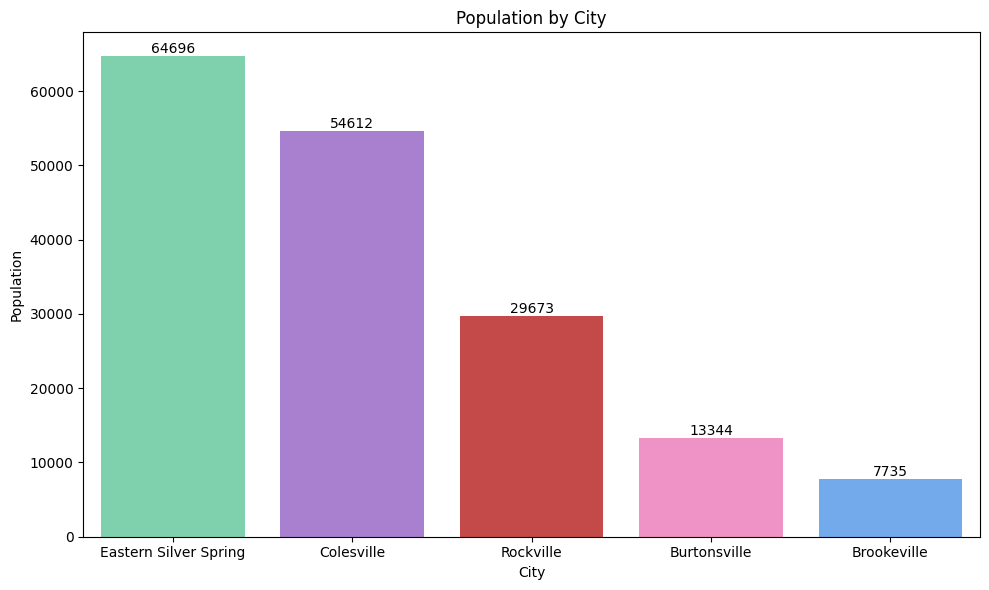

In [162]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=zips,
            x='city_name',
            order=['Eastern Silver Spring',
                   'Colesville',
                   'Rockville',
                   'Burtonsville',
                   'Brookeville'],
            y='population',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title('Population by City')
plt.xlabel('City')
plt.ylabel('Population')

# Put exact population for more detail
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

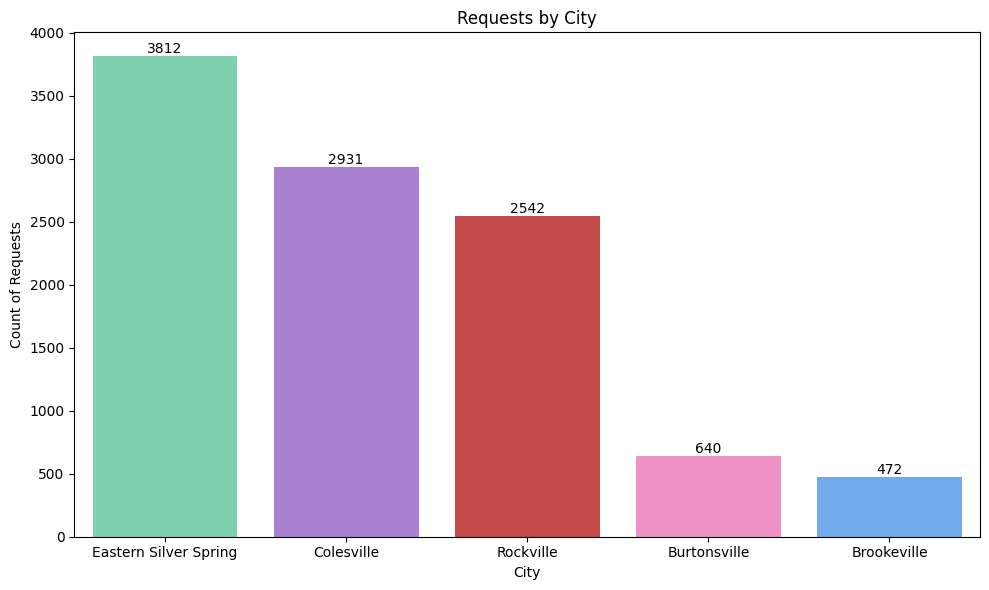

In [163]:
city_counts = mc311['city_name'].value_counts().reset_index()
city_counts.columns = ['city_name', 'count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_counts,
            x='city_name',
            y='count',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title("Requests by City")
plt.xlabel('City')
plt.ylabel('Count of Requests')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

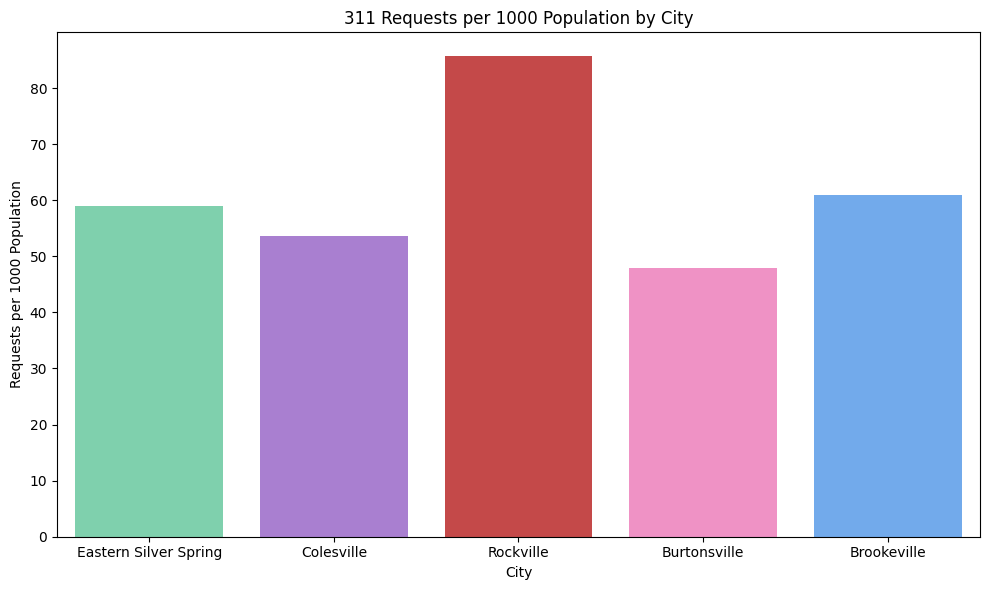

In [160]:
# Group by city_name and count the number of requests
request_counts = merged.groupby('city_name').size().reset_index(name='request_count')

# Get the population and merge with request counts
city_population = merged[['city_name', 'population']].drop_duplicates()
requests_and_population = pd.merge(request_counts, city_population, on='city_name', how='left')

# Calculate requests per capita
requests_and_population['requests_per_capita'] = (requests_and_population['request_count'] / requests_and_population['population']) * 1000

plt.figure(figsize=(10, 6))
sns.barplot(data=requests_and_population,
            x='city_name',
            order=['Eastern Silver Spring',
                   'Colesville',
                   'Rockville',
                   'Burtonsville',
                   'Brookeville'],
            y='requests_per_capita',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title('311 Requests per 1000 Population by City')
plt.xlabel('City')
plt.ylabel('Requests per 1000 Population')
plt.tight_layout()
plt.show()

In [168]:
# Group requests by city_name and area, and count them
requests_by_city_area = merged.groupby(['city_name', 'area']).size().reset_index(name='count')

# Calculate the total requests per city
total_requests_per_city = requests_by_city_area.groupby('city_name')['count'].sum().reset_index(name='total_city_requests')

# Merge to get total requests per city for percentage calculation
requests_by_city_area = pd.merge(requests_by_city_area, total_requests_per_city, on='city_name', how='left')

# Calculate percentage of requests for each area within each city
requests_by_city_area['percentage'] = (requests_by_city_area['count'] / requests_by_city_area['total_city_requests']) * 100

# Create a new column with formatted percentage strings for displaying on bars
requests_by_city_area['formatted_percentage'] = requests_by_city_area['percentage'].apply(lambda x: f'{x:.1f}%')

# Create the stacked bar chart using Plotly Express
fig = px.bar(requests_by_city_area,
             x='city_name',
             y='count',
             color='area',
             title='Total Requests by City, Stacked by Service Area with Percentages',
             labels={'city_name': 'City', 'count': 'Number of Requests', 'area': 'Service Area'},
             category_orders={'city_name': ['Eastern Silver Spring', 'Colesville', 'Rockville', 'Burtonsville', 'Brookeville']},
             hover_data={'count': True, 'percentage': ':.2f'},
             text='formatted_percentage',
             color_discrete_sequence=px.colors.qualitative.Pastel) # Apply pastel color palette

fig.update_layout(barmode='stack')
fig.show()

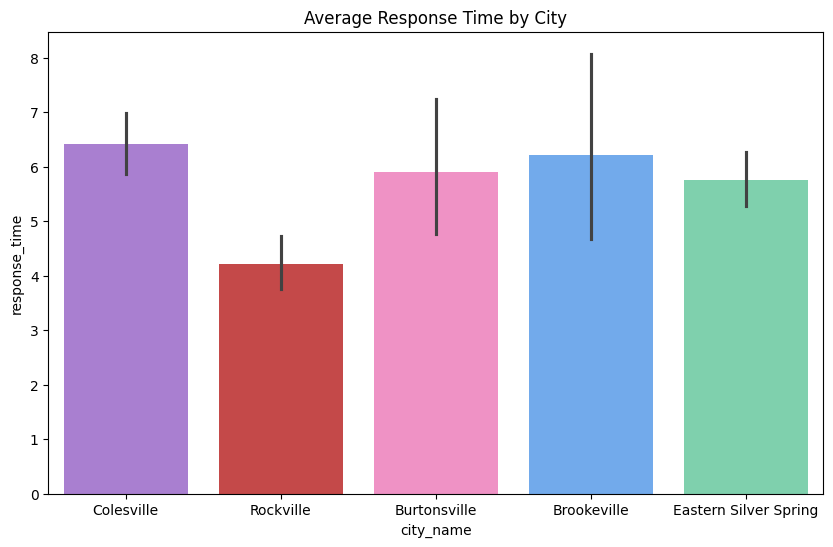

In [127]:
plt.figure(figsize=(10,6))
sns.barplot(data=mc311,
            x='city_name',
            y='response_time',
            hue='city_name',
            palette=city_colors,
            legend=False)
plt.title('Average Response Time by City')
plt.show()

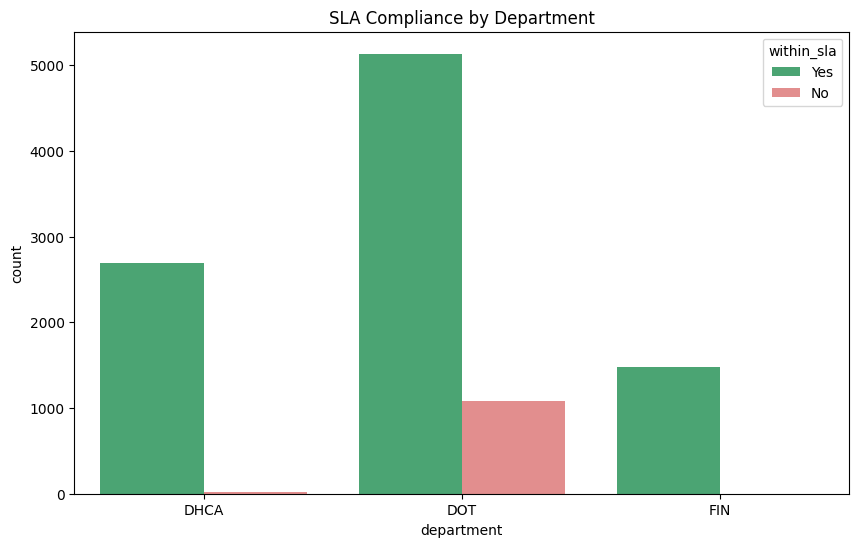

In [139]:
dept_counts = mc311['department'].value_counts().index

plt.figure(figsize=(10,6))
sns.countplot(data=mc311[mc311['department'].isin(dept_counts)],
              x='department',
              hue='within_sla',
              palette={'Yes': 'mediumseagreen',
                       'No': 'lightcoral'},)
plt.title('SLA Compliance by Department')
plt.show()

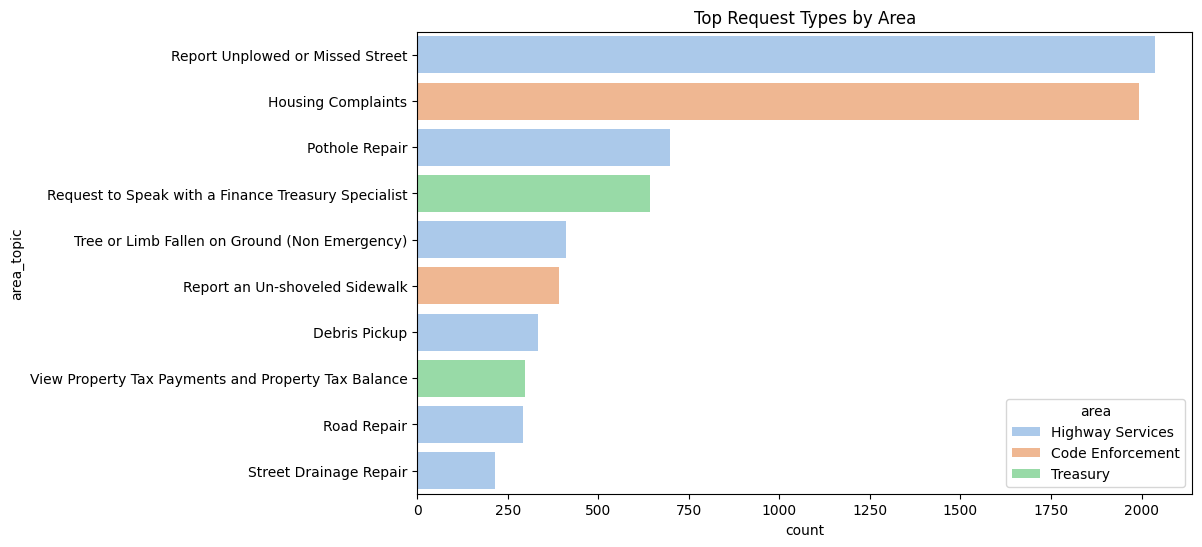

In [50]:
# Find top 10 most requested topics and its counts
topic_count = mc311['area_topic'].value_counts().head(10).reset_index()
topic_count.columns = ['area_topic', 'count']

# Get the corresponding 'area' for each 'area_topic' for bar coloring, and merge
area_topic = mc311[['area_topic', 'area']]
topic_area_count = pd.merge(topic_count, area_topic, on='area_topic', how='left')

plt.figure(figsize=(10, 6))
sns.barplot(data=topic_area_count,
            x='count',
            y='area_topic',
            hue='area',
            palette='pastel')
plt.title("Top Request Types by Area")
plt.show()

In [164]:
top_5 = mc311['area_topic'].value_counts().head(5).index.tolist()
filtered_requests = merged[merged['area_topic'].isin(top_5)]

# Group by city_name and area_topic and count requests
income_topic_requests = filtered_requests.groupby(['city_name', 'area_topic']).agg(request_count=('id', 'count'),).reset_index()

fig = px.bar(income_topic_requests,
             x='city_name',
             y='request_count',
             color='area_topic',
             title='Top 5 Request Types by City',
             labels={'city_name': 'City', 'request_count': 'Number of Requests', 'area_topic': 'Request Type'})
fig.update_layout(barmode='group')
fig.show()

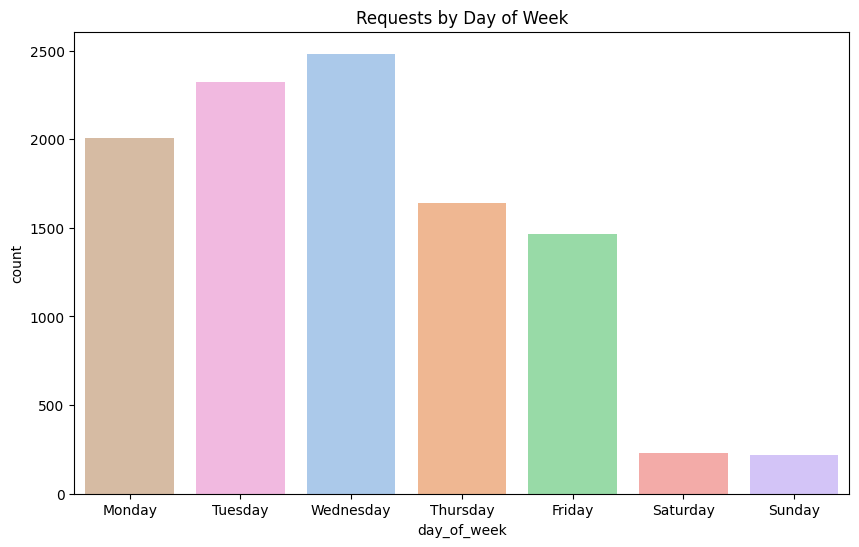

In [52]:
plt.figure(figsize=(10, 6))
sns.countplot(data=mc311,
              x='day_of_week',
              order=['Monday',
                     'Tuesday',
                     'Wednesday',
                     'Thursday',
                     'Friday',
                     'Saturday',
                     'Sunday'],
              hue='day_of_week',
              palette='pastel',
              legend=False)
plt.title("Requests by Day of Week")
plt.show()

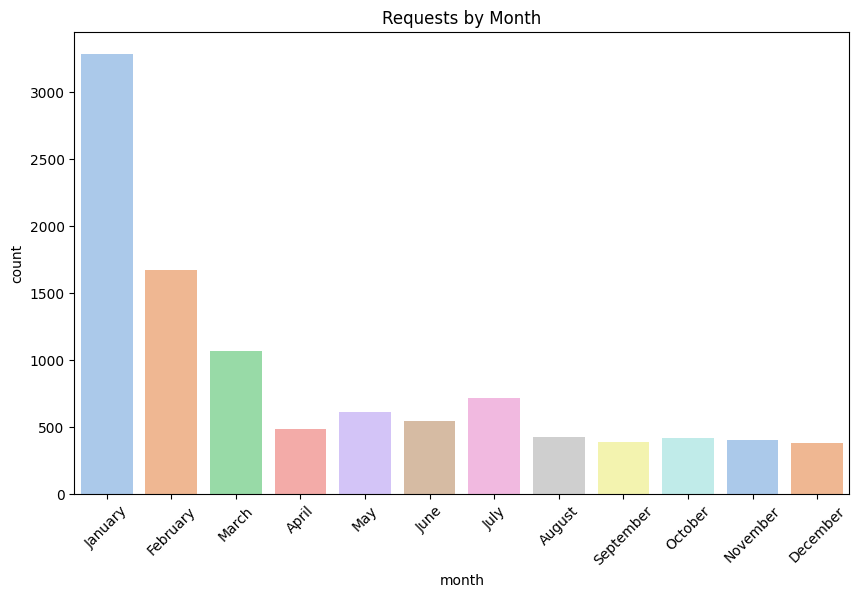

In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(data=mc311,
              x='month',
              hue='month',
              palette='pastel',
              legend=False)
plt.title("Requests by Month")
plt.xticks(rotation=45)
plt.show()

In [43]:
temp_counts = mc311.groupby('avg_temp').size().reset_index(name='count')

fig = px.line(temp_counts, x='avg_temp', y='count',
              title="Requests vs Temperature")
fig.show()